# GenAI-Net tutorial: learn IO-CRN logic circuits (minimal)

This notebook trains an **input-output chemical reaction network (IO-CRN)** to implement
a user-defined **binary logic function** with `n_inputs` inputs.

**How to use this notebook**
1. Edit the **User config** cell (logic function + a few training knobs).
2. Run the notebook top-to-bottom.
3. Stop training anytime with **Ctrl+C (or the stop button)**, inspect results, then resume.


## Install (recommended)

From the repo root:

```bash
pip install -e .
```


## Imports

In [1]:
import numpy as np

from RL4CRN.utils.input_interface import (
    Configurator,
    make_session_and_trainer,
)

from RL4CRN.utils.visualizations import plot_truth_table


## User config (edit this cell)

**Only edit this cell** if you want the simplest experience.


In [2]:
# --- Pick a preset: "fast" | "balanced" | "quality"
cfg = Configurator.preset("fast")

# --- Define your logic function here (vectorized: u is a length-n_inputs array of 0/1 floats)
# Example: (u1 AND NOT u2) OR u3
cfg.task.n_inputs = 3
# cfg.task.logic_fn = lambda u: (bool(u[0]) and (not bool(u[1]))) or bool(u[2])
cfg.task.logic_fn = lambda u: all(u)

# --- Task horizon (optional)
cfg.task.t_f = 100.0
cfg.task.N_t = 1000

# --- Training knobs (optional)
cfg.train.max_added_reactions = 5
cfg.train.epochs = 50             # total target epochs (you may run in chunks below)
cfg.train.render_every = 10       # print progress every N epochs
cfg.train.seed = 0                # reproducibility

# --- Library knobs (optional)
cfg.library.order = 2
cfg.library.include_dilution = False

# --- Solver knobs (optional)
cfg.solver.algorithm = "CVODE"    # or "LSODA"
cfg.solver.rtol = 1e-10
cfg.solver.atol = 1e-10


## Build session + sanity checks

This creates everything needed: task truth table, CRN template, library, environments, policy, agent, trainer.


Device: cuda
CPUs: 128 | Batch size: 1280
Inputs: 3 | Max steps (reactions added): 5



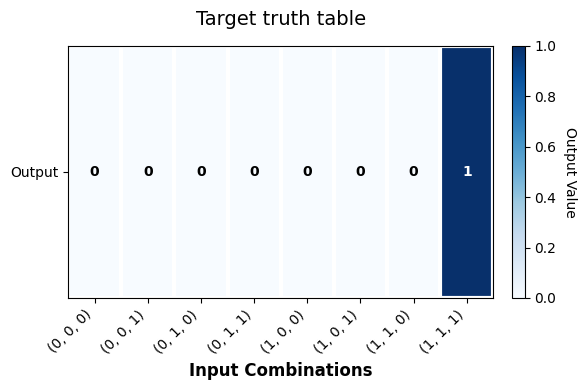

Template IO-CRN:
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]


In [3]:
session, trainer = make_session_and_trainer(cfg, device="auto")

print(f"Device: {session.device}")
print(f"CPUs: {session.n_cpus} | Batch size: {session.batch_size}")
print(f"Inputs: {cfg.task.n_inputs} | Max steps (reactions added): {cfg.train.max_added_reactions}")
print()

# Plot target truth table
plot_truth_table(session.u_list, session.r_list, title="Target truth table")

# Print template CRN summary
print("Template IO-CRN:")
print(session.crn_template)


## Train (stop/resume friendly)

Run training in chunks. You can hit **Ctrl+C** anytime, then inspect and resume.

- `checkpoint_path` saves periodically and also on interrupt.
- Run multiple chunks until you reach your desired quality.


In [4]:
checkpoint_path = "logic_chkpt.pt"

# Example: train in chunks
trainer.run(epochs=cfg.train.epochs, checkpoint_path=checkpoint_path)


[cvHandleFailure, Error: -15] At t = 6.08293321304061, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 19.2878332394828, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 16.4845872339009, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 46.2623448209169, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.83811527672738, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.83813026918763, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 17.5024820156673, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 17.4442114809071, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 13.1692270915543, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 18.3437504025631, unable to satisfy inequality constraints.


[cvHandle

Best loss: 0.055138648936938706
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 + X_2 ----> OUT;  [MAK(0.6132166385650635)]
X_1 + X_3 ----> ∅;  [MAK(0.5966296792030334)]
OUT + X_1 ----> X_1;  [MAK(0.7461986541748047)]
OUT + OUT ----> X_1;  [MAK(0.1335480809211731)]
OUT + OUT ----> X_1 + X_1;  [MAK(0.6173303723335266)]


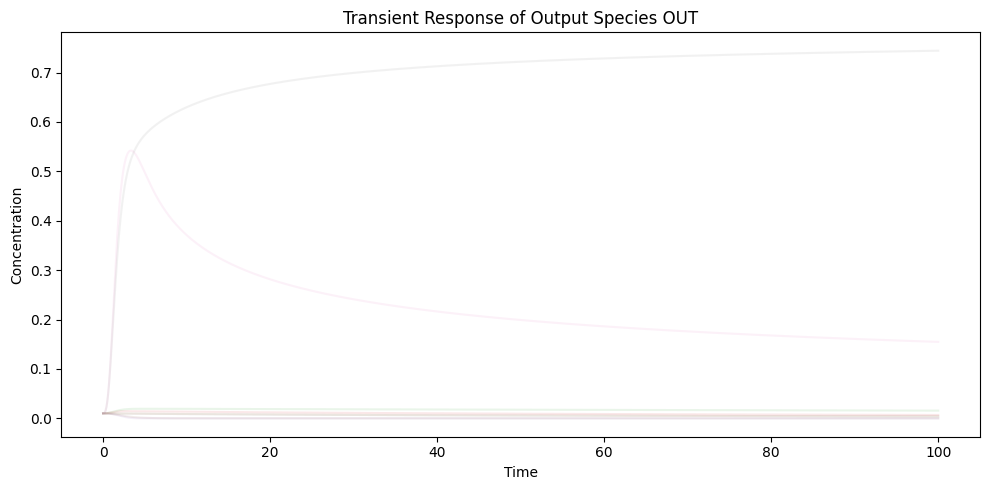

In [5]:
# Inspect best so far (prints CRN + plots transient response if available)
trainer.inspect_best(plot=True)

## Final inspection

Best loss: 0.055138648936938706
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_1 + X_2 ----> OUT;  [MAK(0.6132166385650635)]
X_1 + X_3 ----> ∅;  [MAK(0.5966296792030334)]
OUT + X_1 ----> X_1;  [MAK(0.7461986541748047)]
OUT + OUT ----> X_1;  [MAK(0.1335480809211731)]
OUT + OUT ----> X_1 + X_1;  [MAK(0.6173303723335266)]
Hall of Fame size: 30
Best loss: 0.055138648936938706


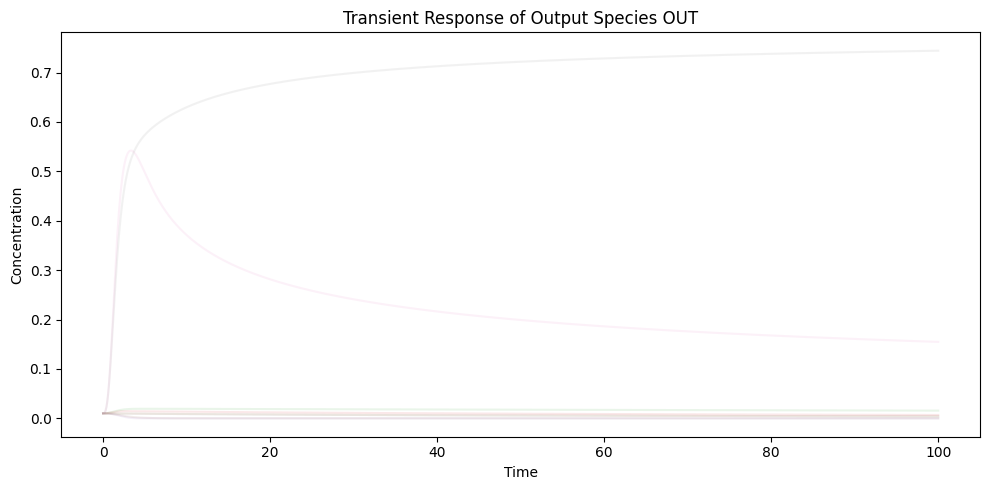

In [6]:
best = trainer.inspect_best(plot=True)

hof_size = len(session.mult_env.hall_of_fame)
print(f"Hall of Fame size: {hof_size}")
if best is not None:
    print("Best loss:", best.last_task_info.get("reward", None))


# Appendix A) All tunable knobs

Everything in the config is editable; the preset only sets defaults.


In [7]:
cfg.describe()

{'task': {'n_inputs': 3,
          'logic_fn': <function <lambda> at 0x7ff2a5e32e60>,
          'input_values': (0.0, 1.0),
          't_f': 100.0,
          'N_t': 1000,
          'ic_value': 0.01,
          'steady_state_weight': 1.0},
 'solver': {'algorithm': 'CVODE', 'rtol': 1e-10, 'atol': 1e-10},
 'train': {'epochs': 50,
           'max_added_reactions': 5,
           'render_every': 10,
           'hall_of_fame_size': 30,
           'batch_multiplier': 10,
           'seed': 0,
           'n_cpus': None,
           'batch_size': None},
 'library': {'order': 2, 'include_dilution': False},
 'policy': {'width': 256,
            'depth': 2,
            'deep_layer_size': 512,
            'continuous_distribution': {'type': 'lognormal_1D', 'dim': 1},
            'entropy_weights_per_head': {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0},
            'ordering_enabled': False,
            'constraint_strength': inf},
 'agent': {'learning_rate': 0.0001,
  

# Appendix B) Resume from checkpoint

If you restart your kernel, you can rebuild and then load the checkpoint.


In [ ]:
# session, trainer = make_session_and_trainer(cfg, device="auto")
# trainer.load("logic_chkpt.pt")
# trainer.inspect_best(plot=True)
# trainer.run(epochs=100, checkpoint_path="logic_chkpt.pt")
